# Single tx dataset

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Test runs

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [4]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.SINGLE,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "mlpbased,ablationsemfusion",

    "num_epochs": 100,
    "learning_rate": 0.005,
    "augment_factor": 0,
    "dme_threshold": 0.5,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
}

In [5]:
# Run with semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=False
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 264 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.3630, val loss: 0.1581, PR-AUC (anomaly): 0.9299, f2-score (anomaly): 0.9420
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       157
           1       0.76      1.00      0.87        39

    accuracy                           0.94       196
   macro avg       0.88      0.96      0.91       196
weighted avg       0.95      0.94      0.94       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.1460, val loss: 0.0934, PR-AUC (anomaly): 0.9137, f2-score (anomaly): 0.9653
              precision    recall  f1-score   sup

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608261903'

In [6]:
# Run without semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=True
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 264 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.4054, val loss: 0.1461, PR-AUC (anomaly): 0.9184, f2-score (anomaly): 0.9653
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       157
           1       0.85      1.00      0.92        39

    accuracy                           0.96       196
   macro avg       0.92      0.98      0.95       196
weighted avg       0.97      0.96      0.97       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.1611, val loss: 0.0917, PR-AUC (anomaly): 0.9124, f2-score (anomaly): 0.9512
              precision    recall  f1-score   sup

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608261909'

## Results processing

In [2]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608261903
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608261909


In [3]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"].get("rm_semantic_fusion", False),
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_es15_mlpbased...,False,264,0.040772,1152,0.2014,0.085195,0.017184,0.968786,...,0.007194,0.933232,0.005228,0.980435,0.001775,0.954231,0.003932,63.450,18.240271,317.25
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_nosf_es15_mlp...,True,264,0.040772,1152,0.2014,0.074574,0.016809,0.966474,...,0.017087,0.929276,0.012406,0.978986,0.004225,0.951109,0.009348,60.718,11.350541,303.59


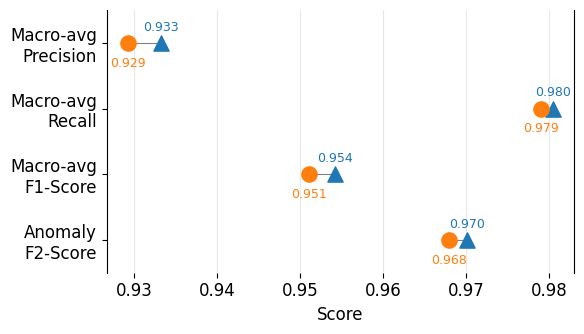

In [5]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "f2_anomaly_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg\nPrecision",
    "Macro-avg\nRecall",
    "Macro-avg\nF1-Score",
    "Anomaly\nF2-Score"
]

plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 3.5))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}
marker_map = {ev: "^" if ev == unique_evals[0] else "o" for ev in unique_evals}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for j, ev_name in enumerate(evals):
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, 16) if j == 0 and abs(plot_df[metric].iloc[0] - plot_df[metric].iloc[1]) < 0.004 else (0, -10),
            ha="center",
            va="top",
            fontsize=9,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=120, color=color_map[ev_name], label=ev_name, zorder=2, marker=marker_map[ev_name])

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
#ax.legend() # UNCOMMENT THIS LINE TO CHECK IF LEGEND IS CORRECT WITH THE MARKERS
plt.tight_layout()

plt.show()

In [6]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.968786,0.002832,1.0,0.0,0.960870,0.003550,0.980041,0.001848,0.866463,...,1.0,0.0,0.928421,0.006016,0.970074,0.002631,0.960138,0.015642,63.450,18.240271
1,True,0.966474,0.006741,1.0,0.0,0.957971,0.008451,0.978515,0.004402,0.858552,...,1.0,0.0,0.923703,0.014294,0.967961,0.006258,0.965322,0.016177,60.718,11.350541


In [7]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,96.88 ± 00.28,96.65 ± 00.67
precision_normal,100.00 ± 00.00,100.00 ± 00.00
recall_normal,96.09 ± 00.35,95.80 ± 00.85
f1_normal,98.00 ± 00.18,97.85 ± 00.44
precision_anomaly,86.65 ± 01.05,85.86 ± 02.48
recall_anomaly,100.00 ± 00.00,100.00 ± 00.00
f1_anomaly,92.84 ± 00.60,92.37 ± 01.43
f2_anomaly,97.01 ± 00.26,96.80 ± 00.63
pr_auc,96.01 ± 01.56,96.53 ± 01.62
fold_time,63.45 ± 18.24,60.72 ± 11.35


In [8]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $96.88 \pm 00.28$ & $96.65 \pm 00.67$ \\
Precision (Normal) (\%) & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ \\
Recall (Normal) (\%) & $96.09 \pm 00.35$ & $95.80 \pm 00.85$ \\
F1 (Normal) (\%) & $98.00 \pm 00.18$ & $97.85 \pm 00.44$ \\
Precision (Anomaly) (\%) & $86.65 \pm 01.05$ & $85.86 \pm 02.48$ \\
Recall (Anomaly) (\%) & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ \\
F1 (Anomaly) (\%) & $92.84 \pm 00.60$ & $92.37 \pm 01.43$ \\
F2 (Anomaly) (\%) & $97.01 \pm 00.26$ & $96.80 \pm 00.63$ \\
PR-AUC (\%) & $96.01 \pm 01.56$ & $96.53 \pm 01.62$ \\
Fold Training Time (sec/fold) & $63.45 \pm 18.24$ & $60.72 \pm 11.35$ \\
\bottomrule
\end{tabular}
\end{table}



# Cross-chain tx scope

In [9]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

## Test runs

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [14]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.CCTX,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "mlpbased,ablationsemfusion",

    "num_epochs": 100,
    "learning_rate": 0.005, # Notice that for the old approach in cctx scope, lr is the same
    "augment_factor": 0,
    "dme_threshold": 0.5,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
}

In [15]:
# Run with semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=False
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 499 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.6344, val loss: 0.4946, PR-AUC (anomaly): 0.5815, f2-score (anomaly): 0.6329
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       197
           1       0.43      0.71      0.54        14

    accuracy                           0.92       211
   macro avg       0.71      0.82      0.75       211
weighted avg       0.94      0.92      0.93       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.4510, val loss: 0.2164, PR-AUC (anomaly): 0.7640, f2-score (anomaly): 0.8235
              precision    recall  f1-score   support

           0       1.00      0.92      0.

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608261915'

In [16]:
# Run without semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=True
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 499 differential meta-paths for training.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.7574, val loss: 0.5878, PR-AUC (anomaly): 0.2117, f2-score (anomaly): 0.0000
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       197
           1       0.00      0.00      0.00        14

    accuracy                           0.93       211
   macro avg       0.47      0.50      0.48       211
weighted avg       0.87      0.93      0.90       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.5732, val loss: 0.3739, PR-AUC (anomaly): 0.7506, f2-score (anomaly): 0.6173
              precision    recall  f1-score   support

           0       0.98      0.92      0.

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608261932'

## Results processing

In [10]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)
print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608261915
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608261932


In [11]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"]["rm_semantic_fusion"] if "rm_semantic_fusion" in doc["params"] else False,
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_es15_mlpbased...,False,499,0.077066,1241,0.0677,0.163092,0.062689,0.983957,...,0.037002,0.940922,0.019389,0.934439,0.019809,0.937538,0.018508,195.394,17.735390,976.97
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_nosf_es15_mlp...,True,499,0.077066,1241,0.0677,0.100550,0.064297,0.983957,...,0.027331,0.937497,0.021394,0.941556,0.029236,0.938265,0.013414,146.214,31.830195,731.07


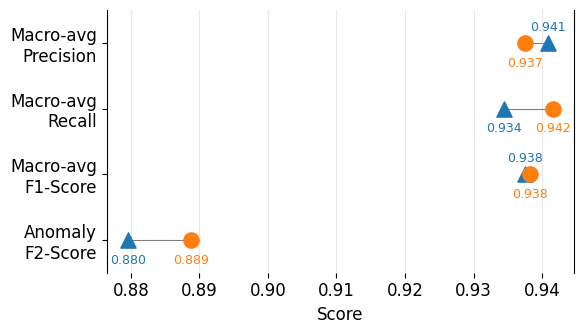

In [15]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "f2_anomaly_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg\nPrecision",
    "Macro-avg\nRecall",
    "Macro-avg\nF1-Score",
    "Anomaly\nF2-Score"
]

plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 3.5))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}
marker_map = {ev: "^" if ev == unique_evals[0] else "o" for ev in unique_evals}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for j, ev_name in enumerate(evals):
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, 16) if j == 0 and abs(plot_df[metric].iloc[0] - plot_df[metric].iloc[1]) < 0.004 else (0, -10),
            ha="center",
            va="top",
            fontsize=9,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=120, color=color_map[ev_name], label=ev_name, zorder=2, marker=marker_map[ev_name])

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
#ax.legend() # UNCOMMENT THIS LINE TO CHECK IF LEGEND IS CORRECT WITH THE MARKERS
plt.tight_layout()

plt.show()

In [16]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.983957,0.004783,0.990818,0.002805,0.991954,0.002816,0.991384,0.002570,0.891026,...,0.876923,0.037684,0.883692,0.034451,0.879567,0.035852,0.886683,0.021711,195.394,17.735390
1,True,0.983957,0.003382,0.991980,0.004578,0.990805,0.004598,0.991374,0.001818,0.883013,...,0.892308,0.061538,0.885156,0.025069,0.888773,0.042954,0.913944,0.018380,146.214,31.830195


In [17]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,98.40 ± 00.48,98.40 ± 00.34
precision_normal,99.08 ± 00.28,99.20 ± 00.46
recall_normal,99.20 ± 00.28,99.08 ± 00.46
f1_normal,99.14 ± 00.26,99.14 ± 00.18
precision_anomaly,89.10 ± 03.67,88.30 ± 04.52
recall_anomaly,87.69 ± 03.77,89.23 ± 06.15
f1_anomaly,88.37 ± 03.45,88.52 ± 02.51
f2_anomaly,87.96 ± 03.59,88.88 ± 04.30
pr_auc,88.67 ± 02.17,91.39 ± 01.84
fold_time,195.39 ± 17.74,146.21 ± 31.83


In [18]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $98.40 \pm 00.48$ & $98.40 \pm 00.34$ \\
Precision (Normal) (\%) & $99.08 \pm 00.28$ & $99.20 \pm 00.46$ \\
Recall (Normal) (\%) & $99.20 \pm 00.28$ & $99.08 \pm 00.46$ \\
F1 (Normal) (\%) & $99.14 \pm 00.26$ & $99.14 \pm 00.18$ \\
Precision (Anomaly) (\%) & $89.10 \pm 03.67$ & $88.30 \pm 04.52$ \\
Recall (Anomaly) (\%) & $87.69 \pm 03.77$ & $89.23 \pm 06.15$ \\
F1 (Anomaly) (\%) & $88.37 \pm 03.45$ & $88.52 \pm 02.51$ \\
F2 (Anomaly) (\%) & $87.96 \pm 03.59$ & $88.88 \pm 04.30$ \\
PR-AUC (\%) & $88.67 \pm 02.17$ & $91.39 \pm 01.84$ \\
Fold Training Time (sec/fold) & $195.39 \pm 17.74$ & $146.21 \pm 31.83$ \\
\bottomrule
\end{tabular}
\end{table}

